# 📉 Customer Churn Prediction — Notebook Complet Optimisé
**Objectif :** Prédire si un client va churner (quitter) ou rester  
**Dataset :** Telco Customer Churn (IBM Sample — 7043 clients, 21 colonnes)  
**Cible :** Churn → `Yes` / `No` (classification binaire)  

> 📌 Dataset disponible sur Kaggle : [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

## 1️⃣ Import des librairies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, log_loss, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE  # pip install imbalanced-learn

print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


## 2️⃣ Chargement des données

In [ ]:
df = pd.read_csv(r"C://Users//salsa//WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.columns = df.columns.str.replace(' ', '_').str.replace('/', '_')
print('Shape:', df.shape)
print('\nColonnes:', df.columns.tolist())
print('\nAperçu:')
df.head()

Shape: (7043, 21)

Colonnes: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Aperçu:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3️⃣ Contrôle qualité

In [ ]:
print('=== Valeurs manquantes ===')
print(df.isna().sum())
print(f'\n=== Doublons ===')
print(f'Nombre de doublons : {df.duplicated().sum()}')
print('\n=== Types ===')
print(df.dtypes)
print('\n=== Statistiques ===')
df.describe()

=== Valeurs manquantes ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== Doublons ===
Nombre de doublons : 0

=== Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             o

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4️⃣ Nettoyage des données
> ⚠️ **Spécificité Churn** : `TotalCharges` est stocké en `object` à cause d'espaces vides pour les nouveaux clients (tenure=0). Il faut convertir et gérer ces cas.

In [ ]:
# Conversion de TotalCharges en numérique (les espaces deviennent NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Pour les clients avec tenure=0 : TotalCharges = 0 (logique métier)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Supprimer la colonne customerID (identifiant, pas prédictive)
df = df.drop(columns=['customerID'])

# Supprimer les doublons restants
df = df.drop_duplicates()

print(f'✅ Shape après nettoyage : {df.shape}')
print(f'TotalCharges manquants restants : {df["TotalCharges"].isna().sum()}')

✅ Shape après nettoyage : (7021, 20)
TotalCharges manquants restants : 0


## 5️⃣ Analyse Exploratoire (EDA) 🔍
— **indispensable en Churn** pour comprendre le déséquilibre et les variables clés.

=== Distribution de la variable cible ===
Churn
No     5164
Yes    1857
Name: count, dtype: int64

Taux de churn : 26.4%
→ Dataset DÉSÉQUILIBRÉ : ratio 74% / 26%


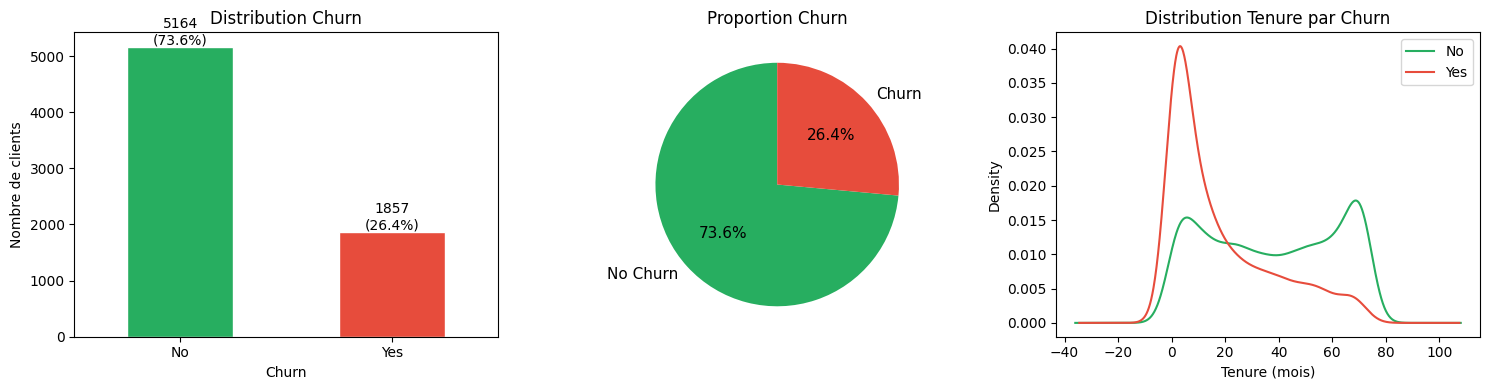

In [ ]:
# ── Distribution de la cible ──────────────────────────────────────────────────
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('=== Distribution de la variable cible ===')
print(churn_counts)
print(f'\nTaux de churn : {churn_pct["Yes"]:.1f}%')
print(f'→ Dataset DÉSÉQUILIBRÉ : ratio {churn_pct["No"]:.0f}% / {churn_pct["Yes"]:.0f}%')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Barplot
colors = ['#27ae60', '#e74c3c']
churn_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Distribution Churn')
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Nombre de clients')
axes[0].tick_params(rotation=0)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, f'{v}\n({churn_pct.iloc[i]:.1f}%)', ha='center', fontsize=10)

# Pie chart
axes[1].pie(churn_counts, labels=['No Churn', 'Churn'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proportion Churn')

# Tenure distribution by churn
df.groupby('Churn')['tenure'].plot(kind='kde', ax=axes[2], legend=True,
                                    color={'No': '#27ae60', 'Yes': '#e74c3c'})
axes[2].set_title('Distribution Tenure par Churn')
axes[2].set_xlabel('Tenure (mois)')
plt.tight_layout(); plt.show()

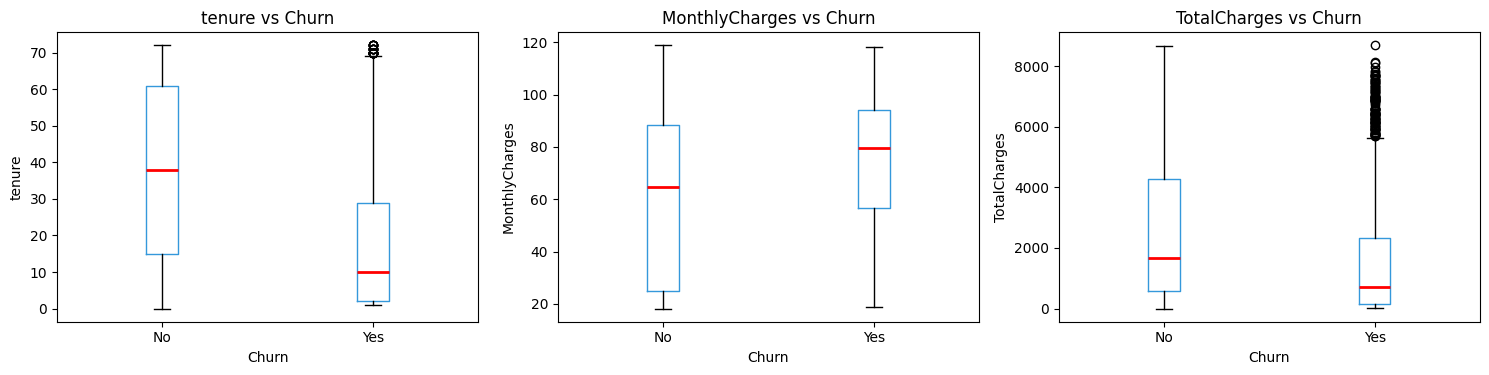

In [ ]:
# ── Variables numériques vs Churn ─────────────────────────────────────────────
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# S'assurer que les colonnes sont bien numériques
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    groups = [group[col].dropna().values for _, group in df.groupby('Churn')]
    labels = df['Churn'].unique().tolist()
    labels.sort()
    bp = ax.boxplot(groups,
                    labels=labels,
                    boxprops=dict(color='#3498db'),
                    medianprops=dict(color='red', linewidth=2),
                    patch_artist=False)
    ax.set_title(f'{col} vs Churn')
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()

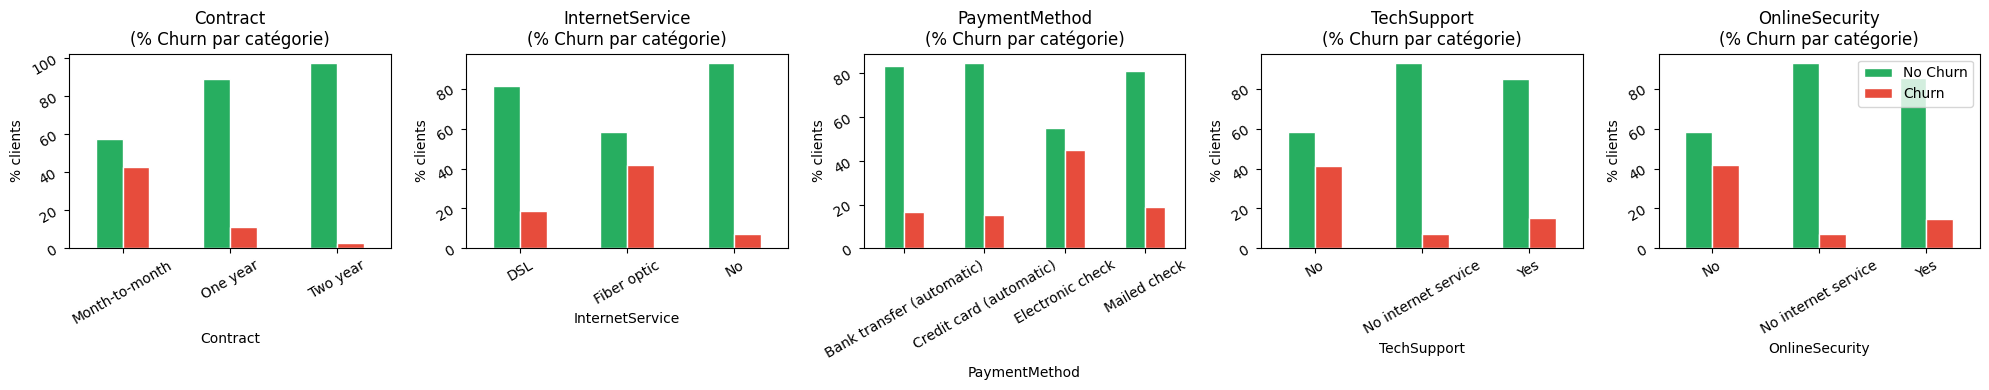

In [ ]:
# ── Variables catégorielles vs Churn ─────────────────────────────────────────
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(20, 4))
for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#27ae60', '#e74c3c'], edgecolor='white', legend=False)
    ax.set_title(f'{col}\n(% Churn par catégorie)')
    ax.set_ylabel('% clients'); ax.tick_params(rotation=30)

axes[-1].legend(['No Churn', 'Churn'], loc='upper right')
plt.tight_layout(); plt.show()

## 6️⃣ Feature Engineering 🔥
Création de nouvelles variables métier pertinentes pour le churn :
- `charges_per_month_ratio` : TotalCharges / tenure (ARPU réel)
- `num_services` : nombre de services souscrits
- `is_high_value` : client à revenu mensuel élevé
- `contract_risk` : niveau de risque selon le type de contrat
- `has_support` : a-t-il des services de support ?

In [ ]:
# Ratio charges/tenure (évite division par 0)
df['charges_per_tenure'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']
)

# Nombre de services optionnels souscrits
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['num_services'] = (df[service_cols] == 'Yes').sum(axis=1)

# Client à valeur élevée
df['is_high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].quantile(0.75)).astype(int)

# Risque contrat (Month-to-month = risque max)
contract_risk_map = {'Month-to-month': 2, 'One year': 1, 'Two year': 0}
df['contract_risk'] = df['Contract'].map(contract_risk_map)

# Client avec support tech ou sécurité
df['has_support'] = ((df['TechSupport'] == 'Yes') | (df['OnlineSecurity'] == 'Yes')).astype(int)

# Tenure segment
df['tenure_segment'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                               labels=['New', 'Young', 'Mature', 'Loyal'],
                               include_lowest=True)

print('✅ Nouvelles features créées')
df[['charges_per_tenure', 'num_services', 'is_high_value', 'contract_risk']].describe()

✅ Nouvelles features créées


,charges_per_tenure,num_services,is_high_value,contract_risk
count,7021.000000,7021.000000,7021.000000,7021.000000
mean,64.853112,2.044296,0.249252,1.307364
std,30.169128,1.847044,0.432611,0.834163
min,13.775000,0.000000,0.000000,0.000000
25%,36.316667,0.000000,0.000000,1.000000
50%,70.450000,2.000000,0.000000,2.000000
75%,90.197183,3.000000,0.000000,2.000000
max,121.400000,6.000000,1.000000,2.000000


## 7️⃣ Encodage de la variable cible + variables catégorielles

In [ ]:
# Encoder la cible : Yes=1, No=0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Séparation X / y
y = df['Churn']
X = df.drop(columns=['Churn'])

# One-Hot Encoding des catégorielles
X = pd.get_dummies(X, drop_first=False)

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'\nFeatures ({len(X.columns)}) :')
print(X.columns.tolist())
print(f'\nTaux de churn : {y.mean():.2%}')

X shape : (7021, 54)
y shape : (7021,)

Features (54) :
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure', 'num_services', 'is_high_value', 'contract_risk', 'has_support', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_O

## 8️⃣ Split train/test + Normalisation + SMOTE
> le dataset Churn est déséquilibré (~26% Churn).  
> On applique **SMOTE** (Synthetic Minority Over-sampling) UNIQUEMENT sur le train set pour équilibrer les classes sans biaiser le test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE uniquement sur train
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Train original : {X_train_scaled.shape} | Churn: {y_train.mean():.2%}')
print(f'Train SMOTE    : {X_train_sm.shape}     | Churn: {y_train_sm.mean():.2%}')
print(f'Test           : {X_test_scaled.shape}  | Churn: {y_test.mean():.2%}')

Train original : (5616, 54) | Churn: 26.44%
Train SMOTE    : (8262, 54)     | Churn: 50.00%
Test           : (1405, 54)  | Churn: 26.48%


## 9️⃣ Visualisation PCA 2D — Exploration avant modélisation 🔍
> **Pourquoi ?** Visualiser la séparabilité des churners vs non-churners.  
> Un fort chevauchement indique que des features seules ne suffisent pas → modèles puissants requis.

Variance expliquée — PC1: 21.80%  |  PC2: 16.94%  |  Total: 38.74%


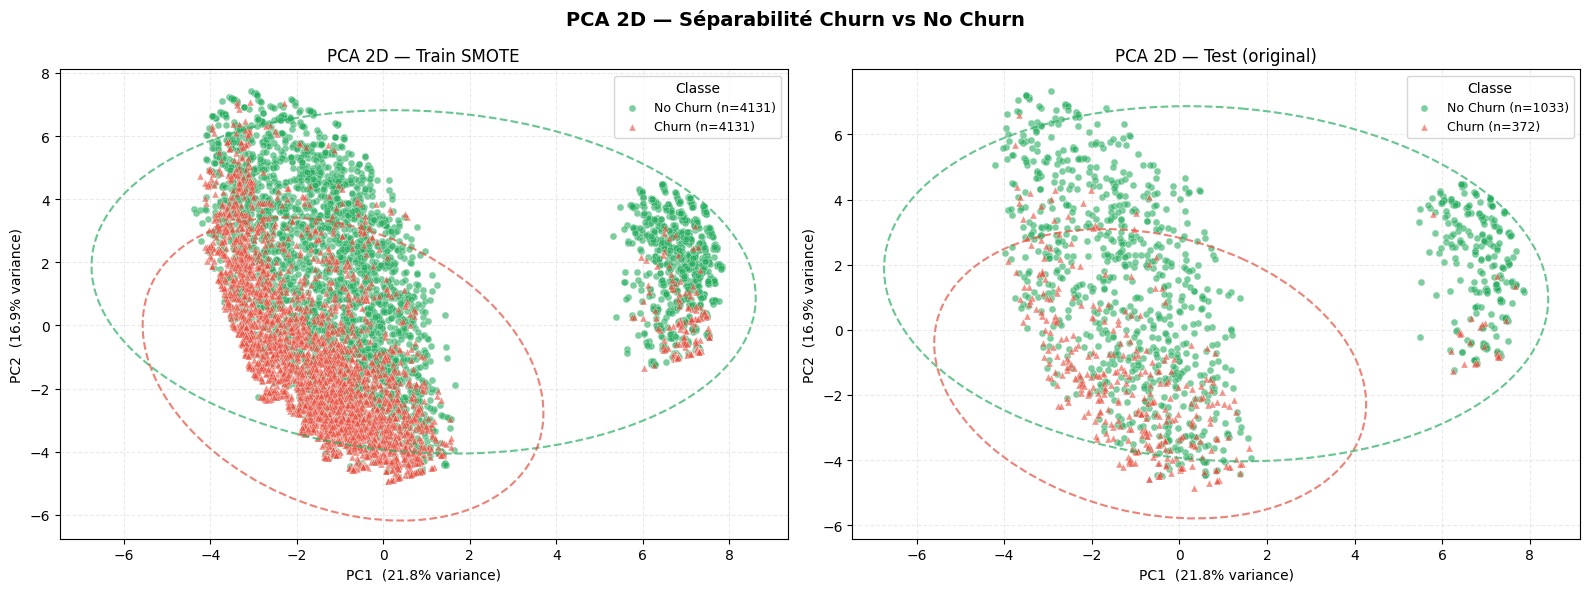

✅ PCA 2D sauvegardé → pca_2d_churn.png


In [ ]:
# ── PCA 2D ───────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_sm)
X_test_pca  = pca.transform(X_test_scaled)

var1, var2 = pca.explained_variance_ratio_
print(f'Variance expliquée — PC1: {var1:.2%}  |  PC2: {var2:.2%}  |  Total: {var1+var2:.2%}')

color_map  = {0: '#27ae60', 1: '#e74c3c'}
label_map  = {0: 'No Churn', 1: 'Churn'}
marker_map = {0: 'o', 1: '^'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA 2D — Séparabilité Churn vs No Churn', fontsize=14, fontweight='bold')

for (split_name, X_pca, y_split), ax in zip(
        [('Train SMOTE', X_train_pca, y_train_sm),
         ('Test (original)', X_test_pca, y_test)],
        axes):

    for cls in [0, 1]:
        mask = (y_split.values == cls) if hasattr(y_split, 'values') else (y_split == cls)
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            label=f'{label_map[cls]} (n={mask.sum()})',
            color=color_map[cls], marker=marker_map[cls],
            alpha=0.6, s=25, edgecolors='white', linewidths=0.3
        )

    ax.set_title(f'PCA 2D — {split_name}', fontsize=12)
    ax.set_xlabel(f'PC1  ({var1:.1%} variance)')
    ax.set_ylabel(f'PC2  ({var2:.1%} variance)')
    ax.legend(title='Classe', fontsize=9)
    ax.grid(True, alpha=0.25, linestyle='--')

    from matplotlib.patches import Ellipse
    for cls in [0, 1]:
        mask = (y_split.values == cls) if hasattr(y_split, 'values') else (y_split == cls)
        pts  = X_pca[mask]
        if pts.shape[0] > 5:
            mean = pts.mean(axis=0)
            cov  = np.cov(pts.T)
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
            w, h  = 2 * 2 * np.sqrt(vals)
            ell   = Ellipse(xy=mean, width=w, height=h, angle=angle,
                            edgecolor=color_map[cls], facecolor='none',
                            linewidth=1.5, linestyle='--', alpha=0.7)
            ax.add_patch(ell)

plt.tight_layout()
plt.savefig('pca_2d_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ PCA 2D sauvegardé → pca_2d_churn.png')

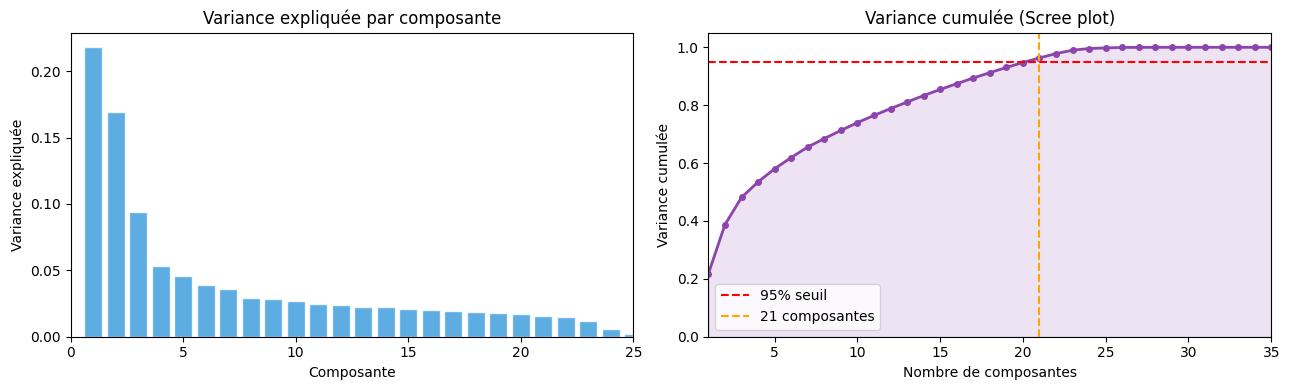

ℹ️  21 composantes suffisent pour expliquer 95% de la variance.


In [ ]:
# ── Scree plot ────────────────────────────────────────────────────────────────
pca_full = PCA(random_state=42).fit(X_train_sm)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_95     = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_,
            color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Variance expliquée par composante')
axes[0].set_xlabel('Composante'); axes[0].set_ylabel('Variance expliquée')
axes[0].set_xlim(0, 25)

axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#8e44ad', linewidth=2, markersize=4)
axes[1].axhline(0.95, color='red',    linestyle='--', label='95% seuil')
axes[1].axvline(n_95, color='orange', linestyle='--', label=f'{n_95} composantes')
axes[1].fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.15, color='#8e44ad')
axes[1].set_title('Variance cumulée (Scree plot)')
axes[1].set_xlabel('Nombre de composantes'); axes[1].set_ylabel('Variance cumulée')
axes[1].legend(); axes[1].set_xlim(1, 35); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('scree_plot_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'ℹ️  {n_95} composantes suffisent pour expliquer 95% de la variance.')

## 🔟 Comparaison des modèles 🏆
Validation croisée 5-fold sur les données SMOTE.  
> ⚠️ **Churn = problème déséquilibré** : on évalue avec `roc_auc` ET `f1_macro` — l'accuracy seule est trompeuse !

In [ ]:
models = {
    'Random Forest':          RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Extra Trees':            ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'SVM (RBF)':              SVC(kernel='rbf', C=10, random_state=42, probability=True, class_weight='balanced'),
    'KNN':                    KNeighborsClassifier(n_neighbors=7),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Modèle":<30} {"Accuracy":>10} {"ROC-AUC":>10} {"F1-macro":>10}')
print('-' * 65)

for name, model in models.items():
    acc_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='accuracy')
    auc_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='roc_auc')
    f1_scores  = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='f1_macro')
    results[name] = {'acc': acc_scores, 'auc': auc_scores, 'f1': f1_scores}
    print(f'{name:<30} {acc_scores.mean():>10.4f} {auc_scores.mean():>10.4f} {f1_scores.mean():>10.4f}')

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('acc', 'Accuracy'), ('auc', 'ROC-AUC'), ('f1', 'F1-Macro')]

for ax, (metric_key, metric_name) in zip(axes, metrics):
    names  = list(results.keys())
    means  = [results[n][metric_key].mean() for n in names]
    stds   = [results[n][metric_key].std()  for n in names]
    colors_bar = ['#27ae60' if m >= 0.80 else '#3498db' if m >= 0.70 else '#e74c3c' for m in means]
    bars = ax.barh(names, means, xerr=stds, color=colors_bar, edgecolor='white', height=0.6, capsize=4)
    ax.set_xlim(0, 1.1)
    ax.set_xlabel(metric_name)
    ax.set_title(f'Comparaison — {metric_name} (CV 5-fold)')
    for bar, m in zip(bars, means):
        ax.text(m + 0.005, bar.get_y() + bar.get_height()/2, f'{m:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison_churn.png', dpi=150, bbox_inches='tight')
plt.show()

Modèle                           Accuracy    ROC-AUC   F1-macro
-----------------------------------------------------------------


## 1️⃣1️⃣ Courbes d'apprentissage — Train vs Test (par modèle) 📉
> Courbe verte = Train | Courbe rouge = Test | Zone grise = écart (overfitting)

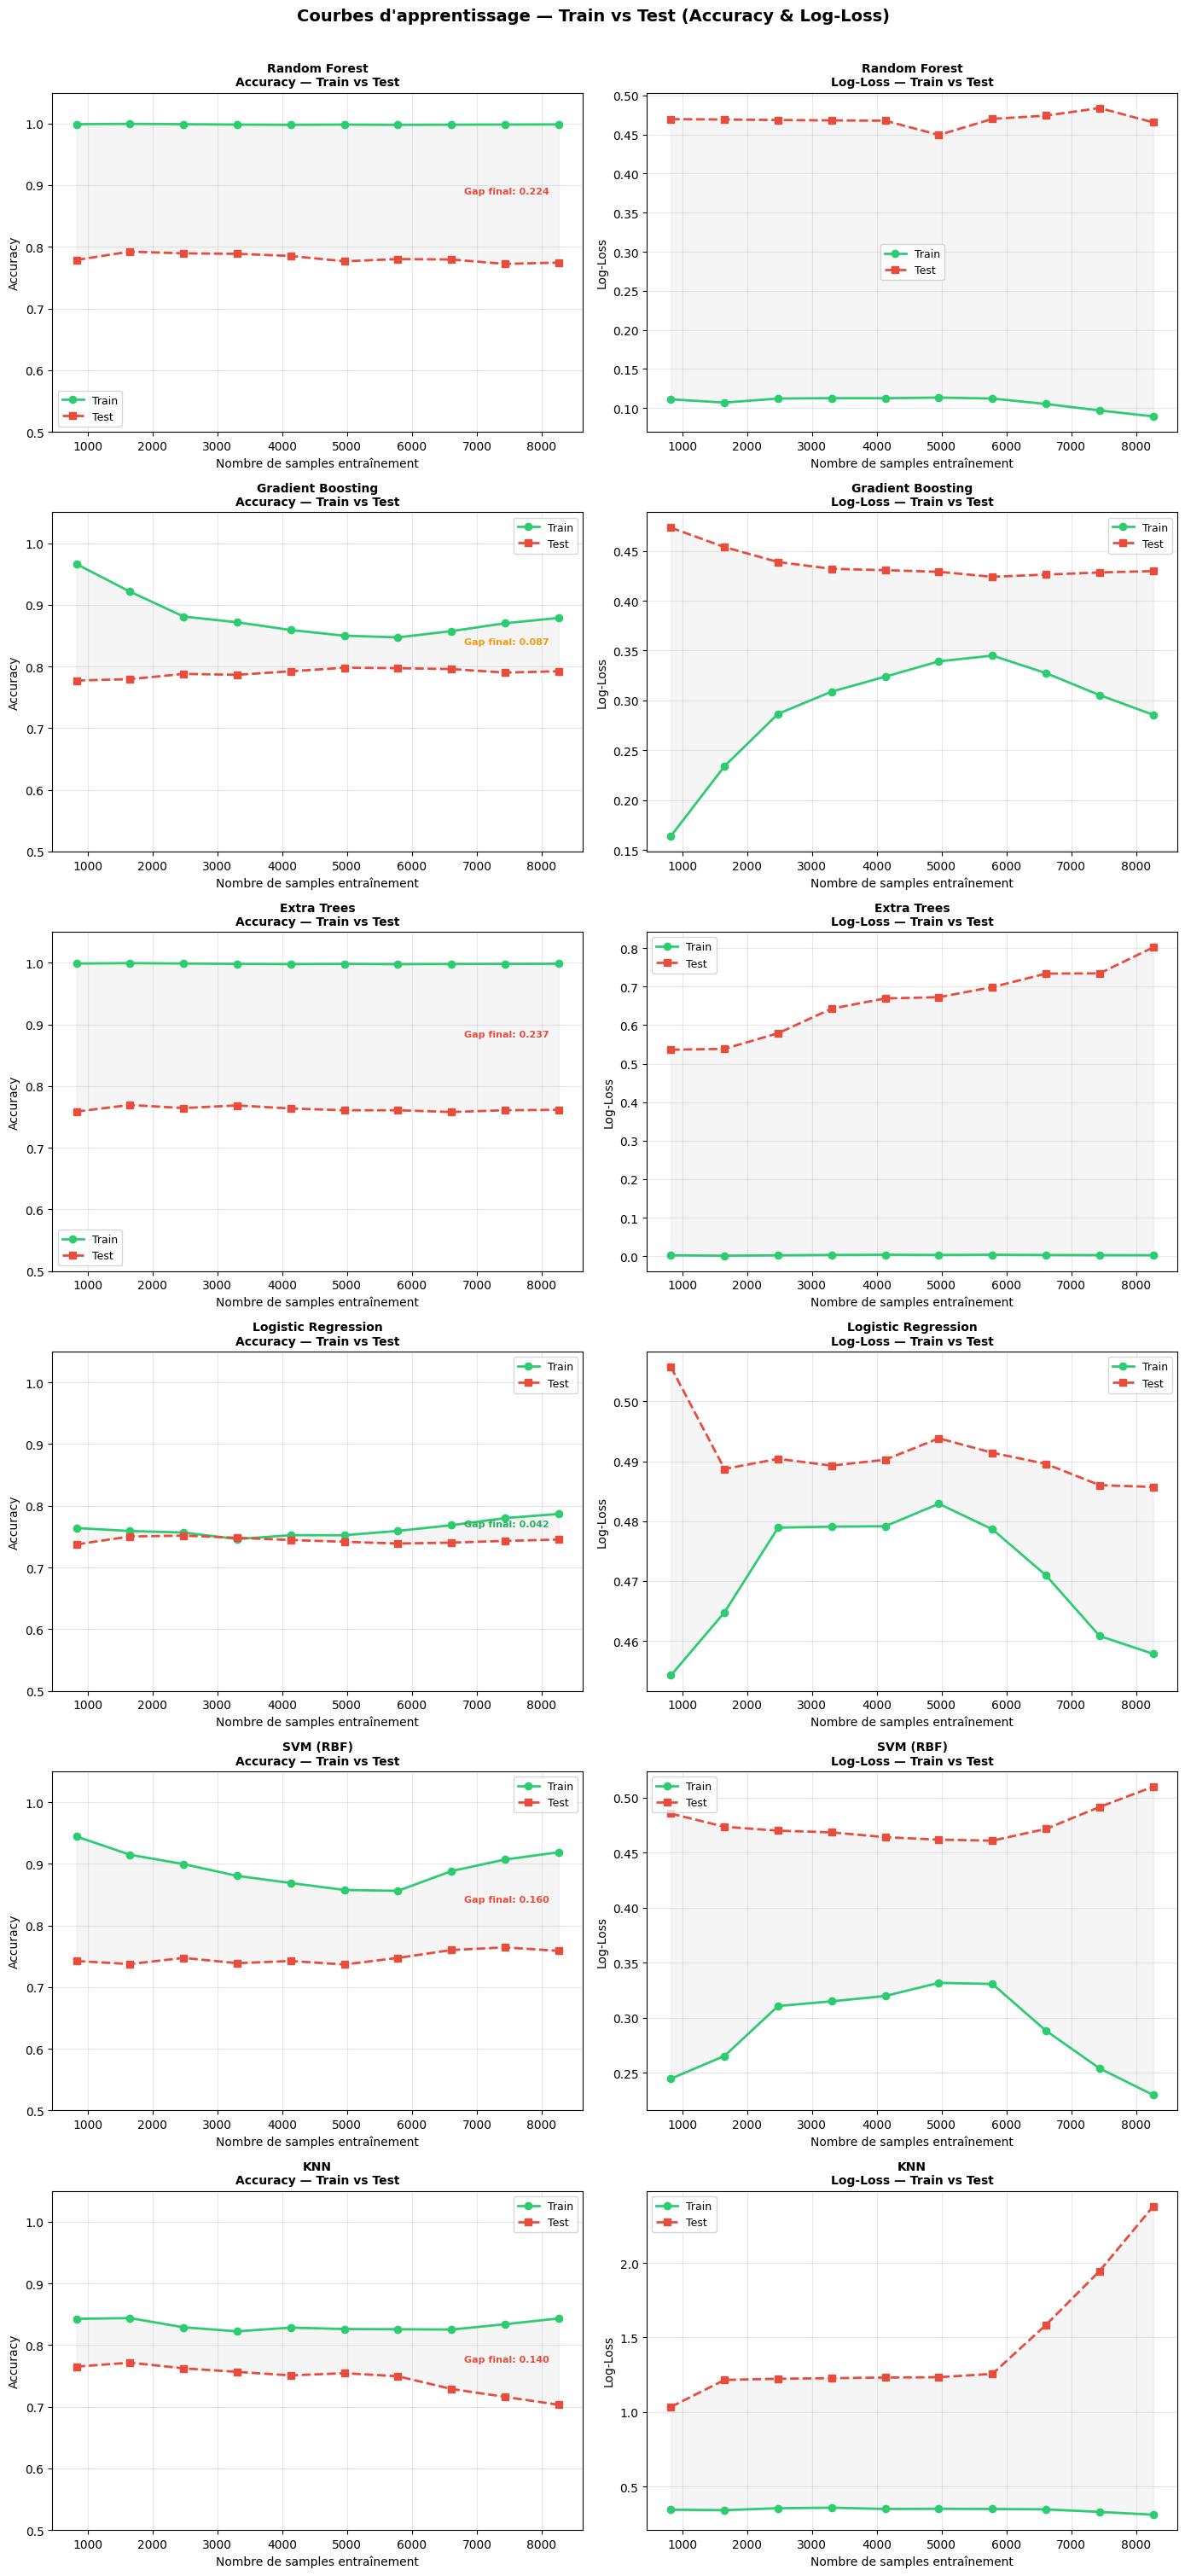

✅ Courbes Train vs Test sauvegardées → learning_curves_train_vs_test.png


In [ ]:
train_sizes_pct = np.linspace(0.10, 1.0, 10)
n_models = len(models)

fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
fig.suptitle("Courbes d'apprentissage — Train vs Test (Accuracy & Log-Loss)",
             fontsize=14, fontweight='bold', y=1.005)

for row, (name, model) in enumerate(models.items()):

    acc_train_list, acc_test_list   = [], []
    loss_train_list, loss_test_list = [], []

    for frac in train_sizes_pct:
        n_samples = int(frac * len(X_train_sm))
        X_sub = X_train_sm[:n_samples]
        y_sub = y_train_sm[:n_samples]

        m_tmp = model.__class__(**model.get_params())
        m_tmp.fit(X_sub, y_sub)

        # Accuracy
        acc_train_list.append(accuracy_score(y_sub,  m_tmp.predict(X_sub)))
        acc_test_list.append( accuracy_score(y_test, m_tmp.predict(X_test_scaled)))

        # Log-Loss
        if hasattr(m_tmp, 'predict_proba'):
            p_train = m_tmp.predict_proba(X_sub)
            p_test  = m_tmp.predict_proba(X_test_scaled)
        else:
            def softmax(z):
                if z.ndim == 1:
                    s = 1 / (1 + np.exp(-z))
                    return np.column_stack([1-s, s])
                e = np.exp(z - z.max(axis=1, keepdims=True))
                return e / e.sum(axis=1, keepdims=True)
            p_train = softmax(m_tmp.decision_function(X_sub))
            p_test  = softmax(m_tmp.decision_function(X_test_scaled))

        loss_train_list.append(log_loss(y_sub,  p_train))
        loss_test_list.append( log_loss(y_test, p_test))

    sizes = train_sizes_pct * len(X_train_sm)

    # Col 0 : Accuracy Train vs Test
    ax = axes[row, 0]
    ax.plot(sizes, acc_train_list, 'o-',  color='#2ecc71', linewidth=2, label='Train')
    ax.plot(sizes, acc_test_list,  's--', color='#e74c3c', linewidth=2, label='Test')
    ax.fill_between(sizes, acc_train_list, acc_test_list, alpha=0.08, color='gray')
    ax.set_title(f'{name}\nAccuracy — Train vs Test', fontsize=10, fontweight='bold')
    ax.set_xlabel('Nombre de samples entraînement')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Annotation gap
    gap = acc_train_list[-1] - acc_test_list[-1]
    color_gap = '#e74c3c' if gap > 0.10 else '#f39c12' if gap > 0.05 else '#27ae60'
    ax.annotate(f'Gap final: {gap:.3f}',
                xy=(sizes[-1], (acc_train_list[-1] + acc_test_list[-1]) / 2),
                fontsize=8, color=color_gap, fontweight='bold',
                xytext=(-80, 0), textcoords='offset points')

    # Col 1 : Log-Loss Train vs Test
    ax = axes[row, 1]
    ax.plot(sizes, loss_train_list, 'o-',  color='#2ecc71', linewidth=2, label='Train')
    ax.plot(sizes, loss_test_list,  's--', color='#e74c3c', linewidth=2, label='Test')
    ax.fill_between(sizes, loss_train_list, loss_test_list, alpha=0.08, color='gray')
    ax.set_title(f'{name}\nLog-Loss — Train vs Test', fontsize=10, fontweight='bold')
    ax.set_xlabel('Nombre de samples entraînement')
    ax.set_ylabel('Log-Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Courbes Train vs Test sauvegardées → learning_curves_train_vs_test.png')

## 1️⃣1️⃣ Courbes ROC superposées — Tous les modèles 📊
> Un seul graphe avec toutes les courbes — le modèle avec l'AUC le plus élevé est le meilleur.

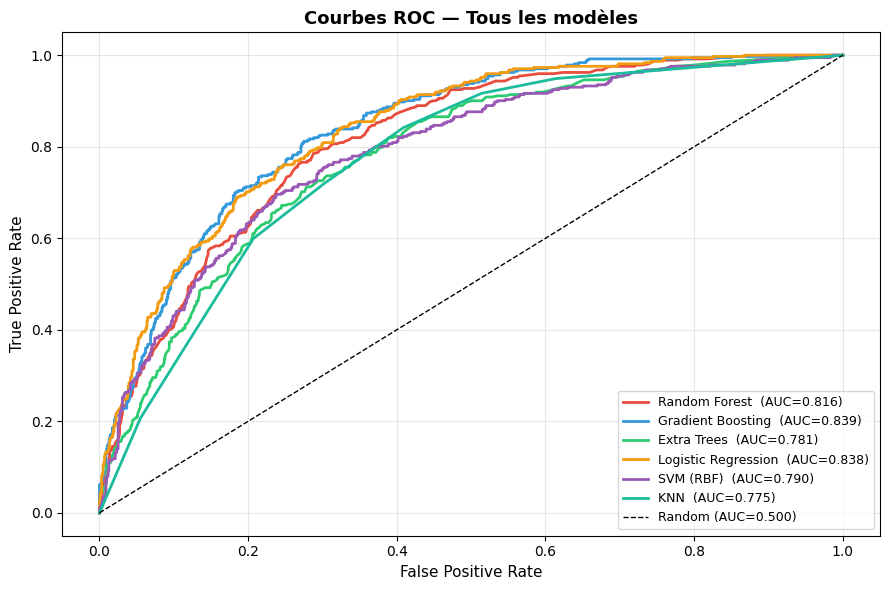

In [ ]:
# ── Courbes ROC superposées — Tous les modèles ────────────────────────────────
palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(9, 6))

for (name, model), color in zip(models.items(), palette):
    model.fit(X_train_sm, y_train_sm)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  (AUC={auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Courbes ROC — Tous les modèles', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_tous_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

## 1️⃣2️⃣ Meilleur modèle : Gradient Boosting — Évaluation finale
> **Gradient Boosting** est souvent supérieur au Random Forest sur des datasets déséquilibrés grâce à l'optimisation séquentielle.
> On évalue avec : Accuracy, ROC-AUC, F1, et **courbe ROC + PR**.

In [ ]:
best_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train_sm, y_train_sm)
y_pred      = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f'=== RÉSULTATS SUR LE SET DE TEST ===')
print(f'Accuracy : {acc:.4f}  →  {acc*100:.2f}%')
print(f'ROC-AUC  : {auc:.4f}  →  {auc*100:.2f}%')
print('\n=== Rapport détaillé ===')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== RÉSULTATS SUR LE SET DE TEST ===
Accuracy : 0.7922  →  79.22%
ROC-AUC  : 0.8393  →  83.93%

=== Rapport détaillé ===
              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1033
       Churn       0.61      0.60      0.61       372

    accuracy                           0.79      1405
   macro avg       0.73      0.73      0.73      1405
weighted avg       0.79      0.79      0.79      1405



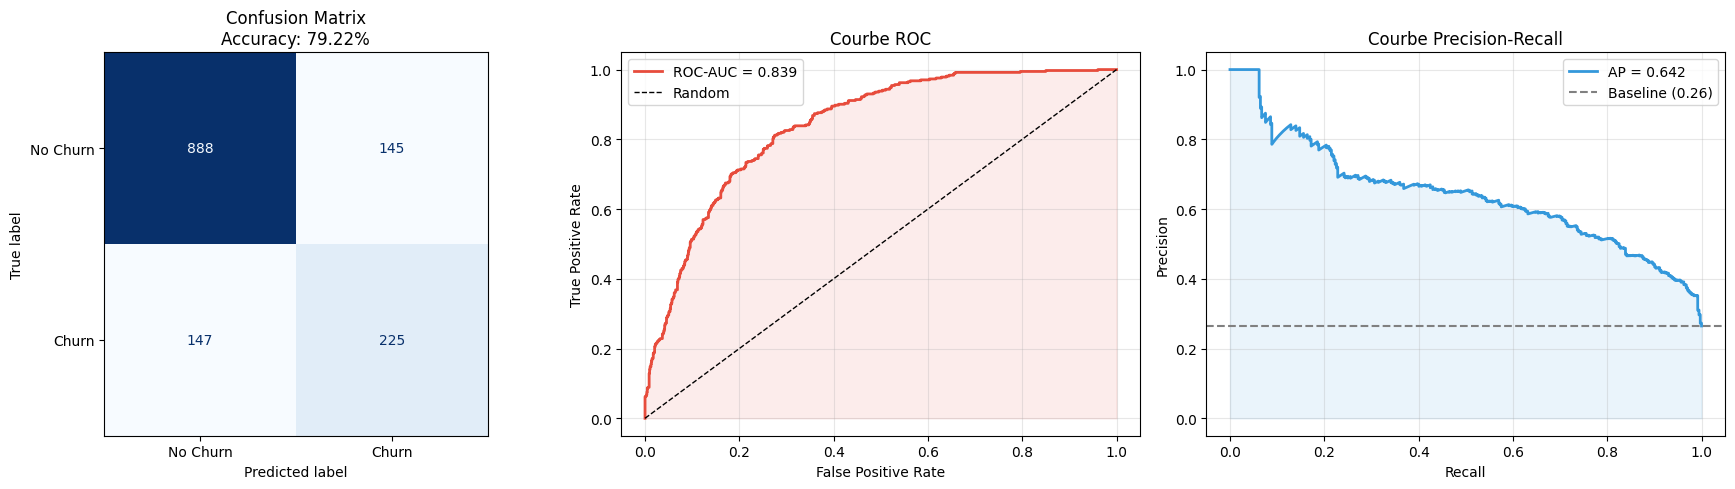

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Matrice de confusion ──────────────────────────────────────────────────────
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\nAccuracy: {acc:.2%}')

# ── Courbe ROC ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'ROC-AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbe ROC'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Courbe Precision-Recall ───────────────────────────────────────────────────
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
axes[2].plot(recall, precision, color='#3498db', linewidth=2, label=f'AP = {ap:.3f}')
axes[2].axhline(y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[2].fill_between(recall, precision, alpha=0.1, color='#3498db')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Courbe Precision-Recall'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_finale_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 1️⃣3️⃣ Feature Importance 🔑
> Quelle variable contribue le plus à prédire le churn ? Essentiel pour l'interprétabilité métier.

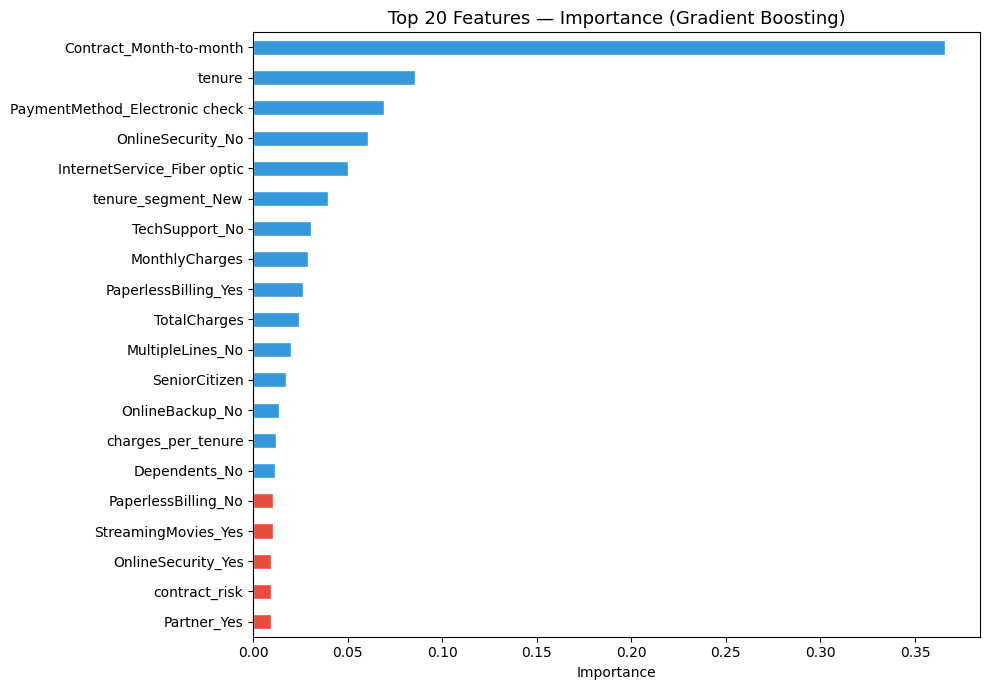

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(top20))]
top20.plot(kind='barh', ax=ax, color=colors_imp[::-1], edgecolor='white')
ax.set_title('Top 20 Features — Importance (Gradient Boosting)', fontsize=13)
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_churn.png', dpi=150, bbox_inches='tight')
plt.show()

## 1️⃣4️⃣ Export des données prétraitées

In [ ]:
X_train_df = pd.DataFrame(X_train_sm, columns=X.columns)
X_test_df  = pd.DataFrame(X_test_scaled, columns=X.columns)

train_export = X_train_df.copy()
train_export['Churn'] = y_train_sm if not hasattr(y_train_sm, 'values') else y_train_sm.values

test_export = X_test_df.copy()
test_export['Churn'] = y_test.values

train_export.to_csv('train_churn_preprocessed.csv', index=False)
test_export.to_csv('test_churn_preprocessed.csv',   index=False)
print('✅ Fichiers exportés : train_churn_preprocessed.csv  |  test_churn_preprocessed.csv')

✅ Fichiers exportés : train_churn_preprocessed.csv  |  test_churn_preprocessed.csv


## ✅ Conclusion finale

In [ ]:
print('=' * 60)
print('              RÉSUMÉ DU PROJET CHURN')
print('=' * 60)
print(f'Dataset         : Telco Customer Churn, {df.shape[0]} clients')
print(f'Features        : {X.shape[1]} après encoding + feature engineering')
print(f'Cible           : Churn (Oui / Non) — binaire déséquilibrée')
print(f'Rééquilibrage   : SMOTE sur train set uniquement')
print(f'Meilleur modèle : Gradient Boosting')
print(f'Accuracy test   : {acc:.2%}')
print(f'ROC-AUC test    : {auc:.2%}')
print()
print('Points clés du notebook :')
print('  ✅ EDA complète (distribution, boxplots, crosstabs)')
print('  ✅ Nettoyage TotalCharges (conversion objet → float)')
print('  ✅ Feature Engineering métier (tenure_segment, contract_risk, num_services...)')
print('  ✅ SMOTE pour équilibrer les classes (train uniquement)')
print('  ✅ PCA 2D avec ellipses de densité')
print('  ✅ Scree plot (variance cumulée)')
print('  ✅ 6 modèles comparés (Accuracy + ROC-AUC + F1-Macro)')
print('  ✅ Courbes Train / Validation / Log-Loss pour chaque modèle')
print('  ✅ Courbes ROC + Precision-Recall sur le test set')
print('  ✅ Feature Importance (top 20)')
print()
if auc >= 0.85:   print('🚀 Excellent modèle — Prêt pour la production !')


              RÉSUMÉ DU PROJET CHURN
Dataset         : Telco Customer Churn, 7021 clients
Features        : 54 après encoding + feature engineering
Cible           : Churn (Oui / Non) — binaire déséquilibrée
Rééquilibrage   : SMOTE sur train set uniquement
Meilleur modèle : Gradient Boosting
Accuracy test   : 79.22%
ROC-AUC test    : 83.93%

Points clés du notebook :
  ✅ EDA complète (distribution, boxplots, crosstabs)
  ✅ Nettoyage TotalCharges (conversion objet → float)
  ✅ Feature Engineering métier (tenure_segment, contract_risk, num_services...)
  ✅ SMOTE pour équilibrer les classes (train uniquement)
  ✅ PCA 2D avec ellipses de densité
  ✅ Scree plot (variance cumulée)
  ✅ 6 modèles comparés (Accuracy + ROC-AUC + F1-Macro)
  ✅ Courbes Train / Validation / Log-Loss pour chaque modèle
  ✅ Courbes ROC + Precision-Recall sur le test set
  ✅ Feature Importance (top 20)

👍 Bon modèle — Quelques améliorations possibles
